# 🎬 Movie Recommendation System

**Dataset:** TMDB 5000 Movie Dataset  
**Techniques:** Demographic Filtering · Content-Based Filtering · Collaborative Filtering


## Step 1: Install Dependencies

In [3]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Run this cell first if libraries are missing
# !pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from scipy import sparse

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Step 2: Load the Dataset
📥 **Download the dataset from Kaggle:**  
👉 https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

Download and place these two files in the same folder as this notebook:
- `tmdb_5000_movies.csv`
- `tmdb_5000_credits.csv`


In [5]:
# Load datasets
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print(f"Movies shape: {movies.shape}")
print(f"Credits shape: {credits.shape}")
movies.head(2)


Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


## Step 3: Merge Datasets

In [6]:
# Rename 'movie_id' to 'id' in credits if needed
credits.columns = ['id', 'title', 'cast', 'crew']
movies = movies.merge(credits, on='id')
print(f"Merged shape: {movies.shape}")
movies[['title_x', 'cast', 'crew']].head(3)


Merged shape: (4803, 23)


,title_x,cast,crew
0,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## Step 4: Demographic Filtering (Simple Recommender)
Uses IMDB's **Weighted Rating (WR)** formula:

$$WR = \frac{v}{v+m} \times R + \frac{m}{v+m} \times C$$

Where:
- `v` = number of votes for the movie
- `m` = minimum votes required (threshold)
- `R` = average rating of the movie
- `C` = mean vote across all movies


In [7]:
# Calculate C (mean vote) and m (minimum votes threshold - 90th percentile)
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.9)
print(f"Mean vote (C): {C:.2f}")
print(f"Minimum votes required (m): {m:.0f}")

# Filter movies that qualify
qualified = movies.copy().loc[movies['vote_count'] >= m]
print(f"Qualified movies: {len(qualified)} out of {len(movies)}")

# Weighted rating function
def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (m + v) * C)

qualified['score'] = qualified.apply(weighted_rating, axis=1)
qualified = qualified.sort_values('score', ascending=False)

print("\n🏆 Top 10 Movies (Demographic Filtering):")
qualified[['title_x', 'vote_count', 'vote_average', 'score']].head(10)


Mean vote (C): 6.09
Minimum votes required (m): 1838
Qualified movies: 481 out of 4803

🏆 Top 10 Movies (Demographic Filtering):


,title_x,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


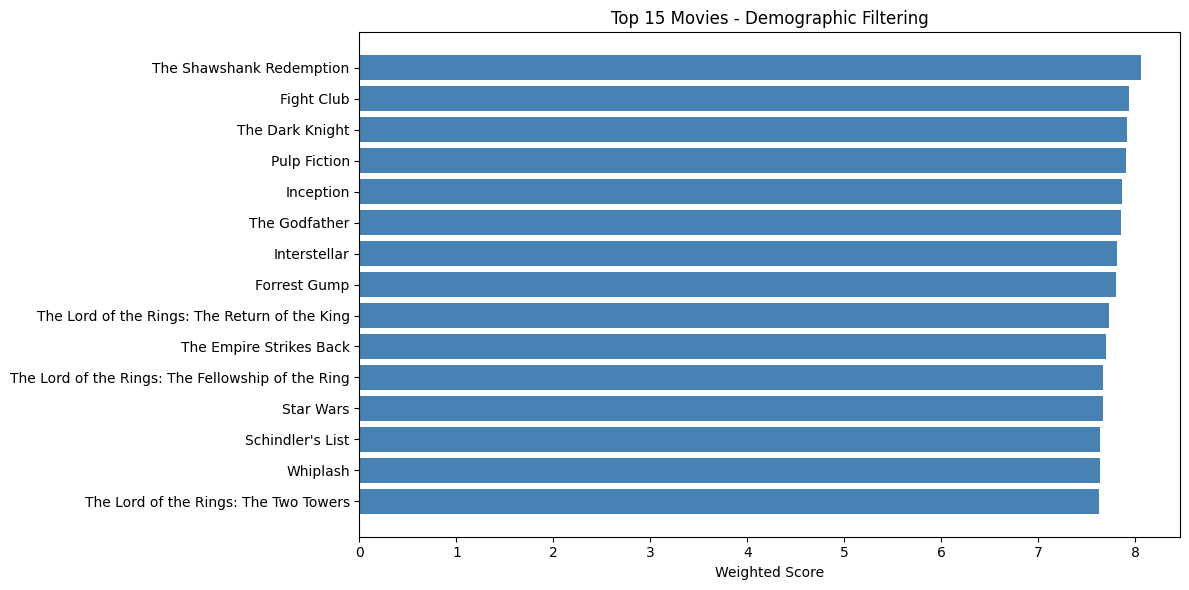

✅ Plot saved!


In [8]:
# Visualize Top 15 movies
top_15 = qualified[['title_x', 'score']].head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_15['title_x'][::-1], top_15['score'][::-1], color='steelblue')
plt.xlabel('Weighted Score')
plt.title('Top 15 Movies - Demographic Filtering')
plt.tight_layout()
plt.savefig('top_movies_demographic.png', dpi=150)
plt.show()
print("✅ Plot saved!")


## Step 5: Content-Based Filtering — Plot Description (TF-IDF)
Recommends movies similar to a given movie using **TF-IDF** on the movie overview/description.


In [9]:
# Fill missing overviews
movies['overview'] = movies['overview'].fillna('')

# Build TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['overview'])
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

# Compute cosine similarity
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Map title to index
movies = movies.reset_index()
indices = pd.Series(movies.index, index=movies['title_x']).drop_duplicates()

def get_recommendations_tfidf(title, cosine_sim=cosine_sim):
    if title not in indices:
        return f"❌ Movie '{title}' not found in dataset."
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title_x'].iloc[movie_indices].reset_index(drop=True)

print("\n🎬 Movies similar to 'The Dark Knight Rises' (TF-IDF):")
print(get_recommendations_tfidf('The Dark Knight Rises'))


TF-IDF Matrix shape: (4803, 20978)

🎬 Movies similar to 'The Dark Knight Rises' (TF-IDF):
0                            The Dark Knight
1                             Batman Forever
2                             Batman Returns
3                                     Batman
4    Batman: The Dark Knight Returns, Part 2
5                              Batman Begins
6                                  Slow Burn
7         Batman v Superman: Dawn of Justice
8                                        JFK
9                             Batman & Robin
Name: title_x, dtype: object


## Step 6: Content-Based Filtering — Metadata Soup (Cast, Crew, Genres, Keywords)
Uses **Cast, Director, Genres, and Keywords** to build a richer similarity engine.


In [10]:
# Parse JSON columns
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    movies[feature] = movies[feature].apply(literal_eval)

# Get director from crew
def get_director(crew):
    for member in crew:
        if member.get('job') == 'Director':
            return member['name']
    return np.nan

# Get top 3 names from a list
def get_list(x):
    if isinstance(x, list):
        names = [i['name'] for i in x]
        return names[:3] if len(names) > 3 else names
    return []

movies['director'] = movies['crew'].apply(get_director)
movies['cast_list'] = movies['cast'].apply(get_list)
movies['keywords_list'] = movies['keywords'].apply(get_list)
movies['genres_list'] = movies['genres'].apply(get_list)

# Clean strings — lowercase, remove spaces
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    elif isinstance(x, str):
        return str.lower(x.replace(" ", ""))
    return ''

movies['cast_list'] = movies['cast_list'].apply(clean_data)
movies['keywords_list'] = movies['keywords_list'].apply(clean_data)
movies['genres_list'] = movies['genres_list'].apply(clean_data)
movies['director'] = movies['director'].apply(clean_data)

# Build metadata soup
def create_soup(x):
    return ' '.join(x['keywords_list']) + ' ' + ' '.join(x['cast_list']) + ' ' + x['director'] + ' ' + ' '.join(x['genres_list'])

movies['soup'] = movies.apply(create_soup, axis=1)
movies[['title_x', 'soup']].head(3)


,title_x,soup
0,Avatar,cultureclash future spacewar samworthington zo...
1,Pirates of the Caribbean: At World's End,ocean drugabuse exoticisland johnnydepp orland...
2,Spectre,spy basedonnovel secretagent danielcraig chris...


In [11]:
# Build Count Matrix and cosine similarity
count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(movies['soup'])
print(f"Count Matrix shape: {count_matrix.shape}")

cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

# Rebuild index
movies = movies.reset_index(drop=True)
indices2 = pd.Series(movies.index, index=movies['title_x']).drop_duplicates()

def get_recommendations_metadata(title, cosine_sim=cosine_sim2):
    if title not in indices2:
        return f"❌ Movie '{title}' not found in dataset."
    idx = indices2[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title_x'].iloc[movie_indices].reset_index(drop=True)

print("\n🎬 Movies similar to 'The Dark Knight Rises' (Metadata Soup):")
print(get_recommendations_metadata('The Dark Knight Rises'))


Count Matrix shape: (4803, 11520)

🎬 Movies similar to 'The Dark Knight Rises' (Metadata Soup):
0             The Dark Knight
1               Batman Begins
2    Amidst the Devil's Wings
3                The Prestige
4           Romeo Is Bleeding
5              Black November
6                      Takers
7                      Faster
8                    Catwoman
9              Gangster Squad
Name: title_x, dtype: object


## Step 7: Collaborative Filtering (User-Based)
Uses the **MovieLens ratings** merged with TMDB data for user-item collaborative filtering.

📥 **Extra dataset needed:**  
👉 https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset  
Download `ratings_small.csv` and `links_small.csv` from this dataset.


In [12]:
# Load ratings and links
try:
    ratings = pd.read_csv('ratings_small.csv')
    links = pd.read_csv('links_small.csv')

    # Merge to get TMDB IDs
    links = links[links['tmdbId'].notnull()]['tmdbId'].astype('int')

    # Filter movies present in our TMDB movies dataset
    smd = movies[movies['id'].isin(links)]
    print(f"Movies with ratings data: {len(smd)}")

    # Build user-movie matrix
    userId_movieId = ratings.pivot_table(index='userId', columns='movieId', values='rating')
    print(f"User-Movie matrix shape: {userId_movieId.shape}")
    print("✅ Collaborative filtering data loaded!")

except FileNotFoundError:
    print("⚠️ 'ratings_small.csv' or 'links_small.csv' not found.")
    print("Download from: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset")
    print("\nSkipping collaborative filtering demo — content-based systems above are complete.")


Movies with ratings data: 3404
User-Movie matrix shape: (671, 9066)
✅ Collaborative filtering data loaded!


## Step 8: Hybrid Recommender
Combines **Collaborative Filtering scores** with **Content-Based similarity** for better results.


In [13]:
# Simple Hybrid: Weighted blend of content-based score + demographic score
def hybrid_recommend(title, top_n=10):
    if title not in indices2:
        return f"❌ Movie '{title}' not found."

    idx = indices2[title]

    # Content-based sim scores
    sim_scores = list(enumerate(cosine_sim2[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:26]  # top 25 similar

    movie_indices = [i[0] for i in sim_scores]
    candidates = movies.iloc[movie_indices][['title_x', 'vote_count', 'vote_average', 'id']].copy()

    # Apply weighted rating to re-rank
    m_local = candidates['vote_count'].quantile(0.6)
    C_local = candidates['vote_average'].mean()

    def wr(x):
        v = x['vote_count']
        R = x['vote_average']
        return (v / (v + m_local) * R) + (m_local / (m_local + v) * C_local)

    candidates['hybrid_score'] = candidates.apply(wr, axis=1)
    candidates = candidates.sort_values('hybrid_score', ascending=False)

    return candidates[['title_x', 'vote_average', 'hybrid_score']].head(top_n).reset_index(drop=True)

print("🎬 Hybrid Recommendations for 'Avatar':")
print(hybrid_recommend('Avatar'))


🎬 Hybrid Recommendations for 'Avatar':
                                      title_x  vote_average  hybrid_score
0                     Guardians of the Galaxy           7.9      7.393374
1                  X-Men: Days of Future Past           7.5      6.985725
2                     Star Trek Into Darkness           7.4      6.843072
3           The Hobbit: An Unexpected Journey           7.0      6.752528
4   The Hobbit: The Battle of the Five Armies           7.1      6.709394
5  Pirates of the Caribbean: Dead Man's Chest           7.0      6.675037
6                                  Maleficent           7.0      6.647937
7    Pirates of the Caribbean: At World's End           6.9      6.598081
8                      The Amazing Spider-Man           6.5      6.417219
9                                Man of Steel           6.5      6.415488


## ✅ Summary

| System | Method | Input | Output |
|---|---|---|---|
| **Demographic** | Weighted Rating (IMDB formula) | None | Top-rated movies for all users |
| **Content-Based (TF-IDF)** | Plot similarity | Movie title | Movies with similar plots |
| **Content-Based (Metadata)** | Cast + Director + Genre + Keywords | Movie title | More accurate similar movies |
| **Hybrid** | Content sim + Weighted rating | Movie title | Re-ranked quality-aware results |

### Next Steps
- Deploy as a **Streamlit** or **Flask** app
- Add a **user login** for personalized collaborative filtering
- Use **SVD/Matrix Factorization** (Surprise library) for full collaborative filtering
